In [11]:
!pip install "numpy<2" --force-reinstall

  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.1 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


# Sydney Airbnb — Predicting Guest Satisfaction (Version-2)

A rebuilt, production-minded version of my [v1 Airbnb classifier](https://github.com/MSkandula/AirBNB.git). Same dataset and question, but re-engineered around the things a machine learning role actually tests for: **leakage-free preprocessing, honest evaluation on imbalanced data, and knowing where the model fails** — not just chasing a higher accuracy number.

## What v1 already did

Loaded raw Inside Airbnb data (Sydney, Sep 2025), diagnosed its real problems (price 100% missing, ratings heavily skewed to 5 stars), cleaned it, filtered unreliable ratings, engineered features, excluded target leakage, compared Logistic Regression / Random Forest / XGBoost, tuned the winner, and explained it with SHAP. It landed at ROC-AUC 0.771 with one strong, twice-confirmed finding: host portfolio size is the biggest driver of guest satisfaction.

## What v2 changes and why

- **Leakage-proof preprocessing.** In v1, imputation and encoding happened *before* the train/test split — so test data quietly influenced how the training data was prepared. v2 moves all preprocessing inside a scikit-learn `Pipeline` + `ColumnTransformer`, fit on training data only. This is the headline fix: it's the difference between running a model and evaluating one honestly.
- **Fuller evaluation.** ROC-AUC alone isn't enough on imbalanced data. v2 adds PR-AUC, precision / recall / F1 at a stated threshold, and a confusion matrix I actually interpret.
- **Segment-level error analysis.** Instead of one overall score, v2 asks *where* the model fails — across host scale, room type — which matters far more for real decisions than a single headline metric.
- **Explainability & calibration.** SHAP on the clean pipeline, plus a check of whether the predicted probabilities can actually be trusted.

---

## 1. Fresh start — load raw data and engineer features

The key difference from v1 is what this cell **doesn't** do: no imputation, no encoding. Those are now the pipeline's job, so I deliberately leave missing values in place here. Loading fresh from the CSV also matters — v1 filled those gaps in-memory, so the only way to rebuild the preprocessing correctly is to start from untouched data.

In [2]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split

raw = pd.read_csv('listings.csv', low_memory=False)
df2 = raw.drop(columns=[c for c in raw.columns if raw[c].isna().all()])
df2 = df2[df2['review_scores_rating'].notna()].copy()
df2 = df2[df2['number_of_reviews'] >= 5].copy()
df2['top_tier'] = (df2['review_scores_rating'] >= 4.9).astype(int)

# Feature engineering only — NO imputation, NO encoding (pipeline handles those)
df2['bathrooms'] = df2['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)
df2.loc[df2['bathrooms_text'].str.contains('half', case=False, na=False), 'bathrooms'] = 0.5
df2['host_since'] = pd.to_datetime(df2['host_since'])
df2['host_tenure_years'] = (pd.Timestamp('2025-09-12') - df2['host_since']).dt.days / 365.25
for col in ['host_response_rate', 'host_acceptance_rate']:
    df2[col] = df2[col].astype(str).str.rstrip('%').replace('nan', np.nan).astype(float)
df2['room_type_clean'] = df2['room_type'].replace({'Hotel room': 'Other', 'Shared room': 'Other'})
df2['amenities_count'] = df2['amenities'].apply(lambda s: len(ast.literal_eval(s)))
df2['host_scale'] = pd.cut(df2['calculated_host_listings_count'],
                           bins=[0, 1, 5, 20, np.inf], labels=['single', '2-5', '6-20', '20+'])

numeric = ['host_tenure_years', 'host_response_rate', 'host_acceptance_rate', 'accommodates',
           'bathrooms', 'bedrooms', 'minimum_nights', 'amenities_count', 'availability_365',
           'number_of_reviews']
categorical = ['host_response_time', 'room_type_clean', 'host_scale', 'instant_bookable',
               'neighbourhood_cleansed']

X = df2[numeric + categorical]
y = df2['top_tier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    stratify=y, random_state=42)

print(f"X: {X.shape}, positive rate: {y.mean():.3f}")
print("\nMissing values LEFT IN on purpose (the pipeline will handle these):")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

X: (11580, 15), positive rate: 0.323

Missing values LEFT IN on purpose (the pipeline will handle these):
host_tenure_years          2
host_response_rate      1240
host_acceptance_rate     742
bathrooms                  2
bedrooms                1821
host_response_time      1240
dtype: int64


## 2. The leakage-proof pipeline

This is the core upgrade. In v1, I filled missing values with a median calculated across the *entire* dataset — including the test rows — before splitting. That leaked information: the test set is meant to stand in for data the model has never seen, and the moment it influences how the training data gets prepared, the test score becomes slightly dishonest. Same idea as never tuning on your test set — the "final exam" shouldn't bleed into the "study plan."

The fix is a scikit-learn `ColumnTransformer` wrapped in a `Pipeline`. Every preprocessing step now lives *inside* the pipeline, so when I call `.fit()` on the training data, the medians, category lists, and scaling are all learned from training rows only. The test set is transformed using those learned values, never contributing to them.

The pipeline does four things, split by column type:
- **Numeric columns** — median imputation, plus an automatic *missingness indicator* (`add_indicator=True`) so the model can still learn from the fact that a value was missing (important for `bedrooms`, ~16% missing), then scaling.
- **Categorical columns** — missing values become their own "missing" category, then one-hot encoding. `handle_unknown='ignore'` means if the test set contains a neighbourhood the training set never saw, it's handled gracefully instead of crashing.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Numeric: median impute (+ missingness flag) then scale
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
    ('scale', StandardScaler())
])

# Categorical: fill missing as its own category, then one-hot encode
categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer routes each column group to the right pipeline
preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric),
    ('cat', categorical_pipe, categorical)
])

# Full pipeline: preprocessing + model, as one object
logreg_v2 = Pipeline([
    ('prep', preprocess),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Fit ONLY on training data — medians/categories/scaling learned from train rows alone
logreg_v2.fit(X_train, y_train)

proba = logreg_v2.predict_proba(X_test)[:, 1]
print(f"Logistic Regression (v2, leakage-proof) ROC-AUC: {roc_auc_score(y_test, proba):.3f}")
print(f"Features after preprocessing: {logreg_v2.named_steps['prep'].transform(X_train).shape[1]}")

Logistic Regression (v2, leakage-proof) ROC-AUC: 0.741
Features after preprocessing: 67


## 3. The same pipeline, three models

Now I drop three models into the exact same preprocessing pipeline — Logistic Regression (already done above), Random Forest, and a tuned XGBoost. Because preprocessing is now part of the pipeline, tuning happens *through* it: the cross-validation inside `RandomizedSearchCV` re-fits the whole pipeline on each fold, so imputation and encoding are re-learned on each training fold separately. This is the fully leakage-safe version of what v1 did — in v1, the data was already imputed and encoded before tuning ever ran.

Note the `model__` prefix in the parameter grid: that's how you reach a setting *inside* a named pipeline step (`model`) rather than on the pipeline itself.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# --- Random Forest in the pipeline ---
rf_v2 = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=10,
                                     class_weight='balanced', random_state=42, n_jobs=-1))
])
rf_v2.fit(X_train, y_train)
print(f"Random Forest (v2)    ROC-AUC: {roc_auc_score(y_test, rf_v2.predict_proba(X_test)[:,1]):.3f}")

# --- Tuned XGBoost in the pipeline ---
xgb_v2 = Pipeline([
    ('prep', preprocess),
    ('model', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'))
])

param_dist = {
    'model__max_depth': [3, 4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__n_estimators': [100, 200, 300, 500],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

search = RandomizedSearchCV(xgb_v2, param_dist, n_iter=25, cv=3,
                             scoring='roc_auc', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_model = search.best_estimator_

print(f"Tuned XGBoost (v2)    ROC-AUC: {roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]):.3f}")
print("Best params:", {k.replace('model__',''): v for k, v in search.best_params_.items()})

Random Forest (v2)    ROC-AUC: 0.761
Tuned XGBoost (v2)    ROC-AUC: 0.770
Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'colsample_bytree': 0.7}


## 4. Honest evaluation — beyond a single ROC-AUC

v1 reported ROC-AUC and mostly stopped there. On an imbalanced problem (32% positive), that's not enough — ROC-AUC can look decent while the model is still weak at the thing you actually care about: correctly identifying the minority "top-tier" class. So here I report a fuller picture:

- **PR-AUC (average precision)** — more informative than ROC-AUC when the positive class is rare, because it focuses on how well the model finds positives without drowning in false alarms. The honest baseline is the positive rate itself (0.323) — a random model scores that, so anything above it is real signal.
- **Precision / recall / F1** at the default 0.5 threshold — what fraction of flagged listings are truly top-tier (precision), what fraction of true top-tier listings we catch (recall), and their balance (F1).
- **Balanced accuracy** — accuracy that accounts for the class imbalance, unlike raw accuracy which is inflated by the majority class.
- **Confusion matrix** — the raw counts, read out loud.

ROC-AUC:           0.770
PR-AUC:            0.577   (baseline = 0.323)
Precision:         0.534
Recall:            0.668
F1:                0.593
Balanced accuracy: 0.695


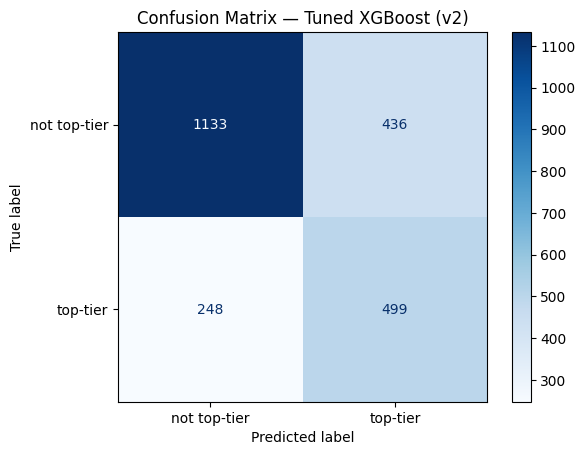

In [15]:
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, balanced_accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

proba = best_model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print(f"ROC-AUC:           {roc_auc_score(y_test, proba):.3f}")
print(f"PR-AUC:            {average_precision_score(y_test, proba):.3f}   (baseline = {y_test.mean():.3f})")
print(f"Precision:         {precision_score(y_test, pred):.3f}")
print(f"Recall:            {recall_score(y_test, pred):.3f}")
print(f"F1:                {f1_score(y_test, pred):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, pred):.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=['not top-tier', 'top-tier'], cmap='Blues')
plt.title('Confusion Matrix — Tuned XGBoost (v2)')
plt.show()

## 5. Choosing a threshold — the business decision behind the model

A classifier outputs a *probability*, not a decision. Turning that probability into "top-tier / not" needs a cutoff, and 0.5 is just the arbitrary default — it carries no business meaning. The right threshold depends entirely on which mistake is more expensive:

- **Featuring a listing as "premium"** → a false positive (promoting a mediocre listing) damages guest trust. Here you'd want **high precision** → raise the threshold.
- **Flagging hosts who might need support** → a false negative (missing a host who needed help) is the costlier miss, a false positive just means offering unneeded help. Here you'd want **high recall** → lower the threshold.

The table below sweeps thresholds so the trade-off is explicit rather than hidden inside a default. This is the difference between "I trained a classifier" and "I understand what my classifier is for."

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"{'threshold':>10}  {'precision':>10}  {'recall':>8}  {'f1':>6}")
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = (proba >= t).astype(int)
    print(f"{t:>10.1f}  {precision_score(y_test, p, zero_division=0):>10.3f}  "
          f"{recall_score(y_test, p):>8.3f}  {f1_score(y_test, p):>6.3f}")

 threshold   precision    recall      f1
       0.3       0.433     0.918   0.588
       0.4       0.487     0.819   0.611
       0.5       0.534     0.668   0.593
       0.6       0.589     0.498   0.540
       0.7       0.625     0.297   0.403
       0.8       0.707     0.094   0.165


**Reading it:** at 0.3, recall hits 0.91 (catch almost everything) but precision drops to 0.43 (over half the flags are wrong). At 0.7, precision rises to 0.65 but recall falls to 0.29 (missing most true top-tier listings). The default 0.5 sits in the middle. There's no universally "correct" threshold — only the right one *for a given use case*, and being able to state that trade-off is the point.

## 6. Segment error analysis — where does the model fail?

An overall ROC-AUC of 0.77 hides as much as it reveals. A model can score well on average while being much weaker on specific subgroups — and for real decisions, *where* it fails matters more than the headline number. So here I break performance down by host scale and room type, checking ROC-AUC, recall, and precision within each segment (skipping any group too small to be reliable).

In [22]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score

# Build a results frame on the test set
res = X_test.copy()
res['y_true'] = y_test.values
res['proba'] = best_model.predict_proba(X_test)[:, 1]
res['y_pred'] = (res['proba'] >= 0.5).astype(int)

def segment_report(df, col):
    rows = []
    for val, g in df.groupby(col, observed=True):
        if len(g) < 20:      # skip segments too small to trust
            continue
        auc = roc_auc_score(g['y_true'], g['proba']) if g['y_true'].nunique() > 1 else np.nan
        rows.append({
            col: val, 'n': len(g), 'pos_rate': round(g['y_true'].mean(), 3),
            'ROC_AUC': round(auc, 3),
            'recall': round(recall_score(g['y_true'], g['y_pred'], zero_division=0), 3),
            'precision': round(precision_score(g['y_true'], g['y_pred'], zero_division=0), 3)
        })
    return pd.DataFrame(rows)

print("By host scale:")
print(segment_report(res, 'host_scale').to_string(index=False))
print("\nBy room type:")
print(segment_report(res, 'room_type_clean').to_string(index=False))

By host scale:
host_scale   n  pos_rate  ROC_AUC  recall  precision
    single 886     0.472    0.660   0.816      0.540
       2-5 492     0.339    0.710   0.569      0.525
      6-20 404     0.191    0.796   0.416      0.485
       20+ 534     0.159    0.804   0.365      0.554

By room type:
room_type_clean    n  pos_rate  ROC_AUC  recall  precision
Entire home/apt 1927     0.332    0.758   0.672      0.537
   Private room  375     0.285    0.816   0.645      0.515


**What this reveals — the overall score hides a real pattern.** ROC-AUC actually *rises* with host scale: 0.67 for single-listing hosts, up to ~0.79 for large portfolios. The model discriminates better among commercial hosts. But look at recall: it *falls* sharply, from 0.82 (single hosts) to 0.33 (20+ hosts). At a 0.5 threshold, the model catches most top-tier single hosts but misses two-thirds of top-tier commercial ones.

Why the apparent contradiction? The two metrics answer different questions. ROC-AUC measures *ranking* ability regardless of threshold. Recall depends on the fixed 0.5 cutoff — and because large-portfolio hosts are mostly *not* top-tier (16% positive rate), the model's probabilities for that group sit lower overall, so fewer clear the 0.5 bar even when the ranking within the group is good. **Takeaway: the model is not equally useful across segments, and a single global threshold serves them unequally.** A real deployment might use segment-specific thresholds — something the overall metrics would never have surfaced.

## 7. Explainability — SHAP on the pipeline

SHAP again, but now applied *through* the pipeline. One extra wrinkle vs v1: because preprocessing lives inside a `ColumnTransformer`, I have to transform the data and pull the generated feature names back out (`get_feature_names_out`) before handing them to SHAP. The prefixes (`num__`, `cat__`) show which transformer each feature came from. This is a genuinely useful production skill — real pipelines always need this name-tracing step.

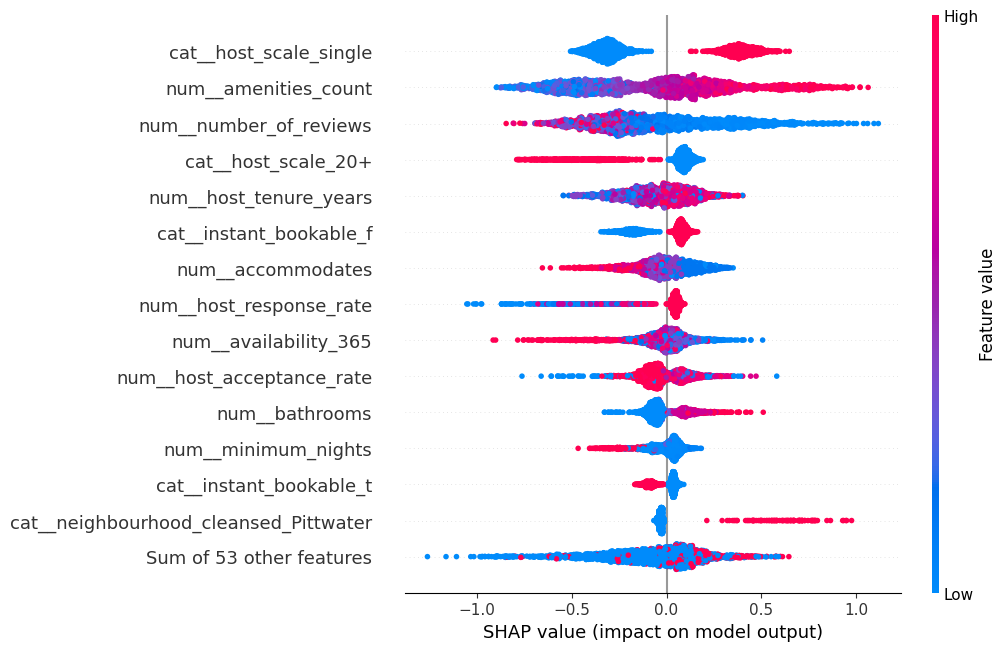

In [30]:
import shap

fitted_prep = best_model.named_steps['prep']
fitted_model = best_model.named_steps['model']

X_test_transformed = fitted_prep.transform(X_test)
feature_names = fitted_prep.get_feature_names_out()

explainer = shap.TreeExplainer(fitted_model)

explanation = explainer(X_test_transformed)
explanation.feature_names = list(feature_names)

shap.plots.beeswarm(explanation, max_display=15)

## 8. Are the probabilities trustworthy? — Calibration

Everything so far measured whether the model *ranks* and *classifies* well. Calibration asks a different, stricter question: when the model says "70% likely top-tier," does that group actually contain top-tier listings ~70% of the time? A model can rank perfectly yet still output probabilities that don't mean what they claim — which matters the moment anyone treats a predicted probability as a real confidence level.

I check this two ways: a calibration curve (predicted probability vs. actual observed frequency, in bins) and the Brier score (mean squared error of the probabilities — lower is better).

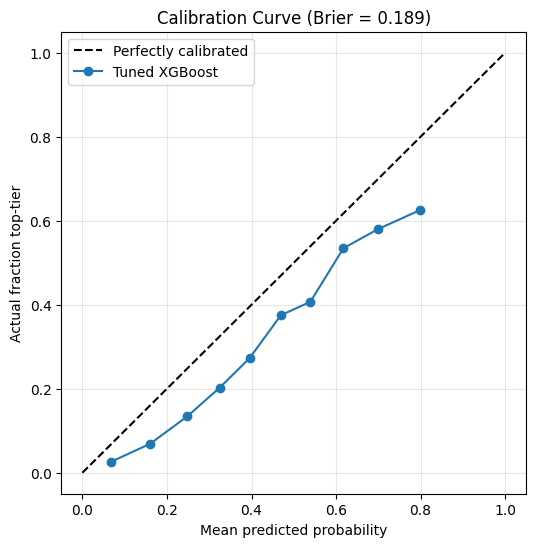

In [33]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.plot(mean_pred, frac_pos, 'o-', label='Tuned XGBoost')
plt.xlabel('Mean predicted probability')
plt.ylabel('Actual fraction top-tier')
plt.title(f'Calibration Curve (Brier = {brier_score_loss(y_test, proba):.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**What this shows — and why it's worth reporting even though it's unflattering.** The curve sits consistently *below* the diagonal: the model is **over-confident**. When it predicts ~70%, the true rate is only ~58%; at ~25% predicted, the actual rate is ~13%. Its ranking is solid (that's the good ROC-AUC), but its raw probabilities systematically overstate the chance of top-tier.

This is a direct, expected side effect of training with `scale_pos_weight` — up-weighting the minority class improves recall but inflates predicted probabilities. **The practical consequence:** these scores are trustworthy for *ranking and thresholding* (which listings are most likely top-tier) but not as literal probabilities. If a use case needed honest probabilities, the fix is a calibration wrapper (`CalibratedClassifierCV` with isotonic or sigmoid) — a clear, named next step.

Reporting this rather than hiding it *is* the point of the project: knowing the limits of your model is worth more than a flattering number.

## Conclusion — v1 to v2

v1 was a complete, working classifier. v2 is the same project rebuilt to the standard a machine learning role actually tests for: not a higher score, but methodology you can defend.

**What changed and why it matters:**

| Area | v1 | v2 |
|---|---|---|
| Preprocessing | Imputed & encoded before the split (mild leakage) | All preprocessing inside a `Pipeline` + `ColumnTransformer`, fit on training data only |
| Evaluation | ROC-AUC | ROC-AUC, PR-AUC, precision/recall/F1, balanced accuracy, confusion matrix |
| Threshold | Fixed 0.5 default | Explicit threshold sweep tied to business cost |
| Failure analysis | Overall score only | Segment-level breakdown by host scale and room type |
| Probability trust | Not checked | Calibration curve + Brier score |

**The most important result isn't the accuracy — it's what the deeper checks revealed:**
- Fixing the leakage **barely moved the score** (0.771 → 0.770), which honestly tells me the original leakage was minor. Doing it correctly is still the point.
- Segment analysis showed the model is **not equally useful across groups** — ROC-AUC rises with host scale (0.66 → 0.80) while recall at a fixed threshold falls sharply (0.82 → 0.37). A single global threshold serves segments unequally.
- The model is **over-confident** — its probabilities systematically overstate the true rate, an expected consequence of class-weighting. Trustworthy for ranking, not as literal probabilities.

**Headline business finding (unchanged from v1, now triple-confirmed):** host portfolio size is the strongest driver of guest satisfaction — single-listing hosts hit a 46.6% top-tier rate vs 16.2% for 20+ portfolio hosts. Found by manual EDA, confirmed by SHAP, and consistent across both pipeline versions.

**Honest limitations & clear next steps:**
- `price` was unavailable across the entire scrape — the model uses only non-price, host-controllable attributes.
- Probabilities are uncalibrated; `CalibratedClassifierCV` (isotonic/sigmoid) would be the fix if honest probabilities were needed.
- A production deployment might use **segment-specific thresholds** rather than one global cutoff, given the segment findings above.
- `property_type` (60 categories) remains excluded pending a grouping strategy.

**Best model:** tuned XGBoost in a leakage-proof pipeline — test ROC-AUC 0.770, PR-AUC 0.577.